# Module 03: EDA

In [1]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [2]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [3]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [4]:
for col in Hitters.columns:
    print(f'{col}: {Hitters[col].dtype}')

AtBat: int64
Hits: int64
HmRun: int64
Runs: int64
RBI: int64
Walks: int64
Years: int64
CAtBat: int64
CHits: int64
CHmRun: int64
CRuns: int64
CRBI: int64
CWalks: int64
League: category
Division: category
PutOuts: int64
Assists: int64
Errors: int64
Salary: float64
NewLeague: category


### Before doing any other analyses, let's create training and test sets.

In [5]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The six columns beginning with `C` contain each player's cumulative **career** totals through 1986. The six corresponding columns without `C` contain statistics from the **1986 season only**. For example, `CHits` is career hits, while `Hits` is hits during 1986.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

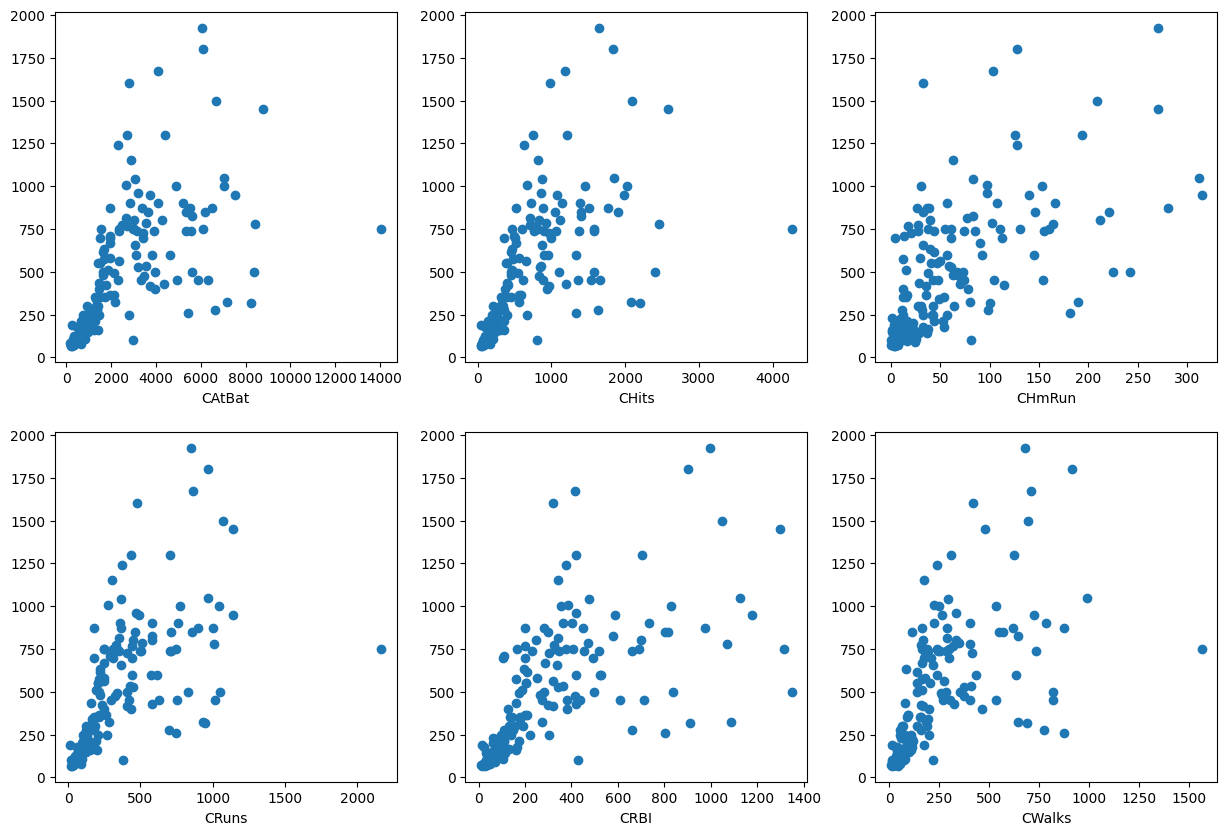

In [6]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [7]:
Train.describe()

            AtBat        Hits       HmRun  ...     Assists      Errors       Salary
count  193.000000  193.000000  193.000000  ...  193.000000  193.000000   164.000000
mean   381.829016  101.549223   10.150259  ...  105.300518    8.051813   493.032951
std    145.679181   44.267521    8.228711  ...  137.135778    6.783667   386.159522
min     19.000000    7.000000    0.000000  ...    0.000000    0.000000    67.500000
25%    271.000000   68.000000    4.000000  ...    7.000000    3.000000   160.000000
50%    369.000000   95.000000    8.000000  ...   38.000000    6.000000   420.833500
75%    508.000000  136.000000   14.000000  ...  173.000000   12.000000   750.000000
max    687.000000  223.000000   40.000000  ...  492.000000   32.000000  1925.571000

[8 rows x 17 columns]

### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

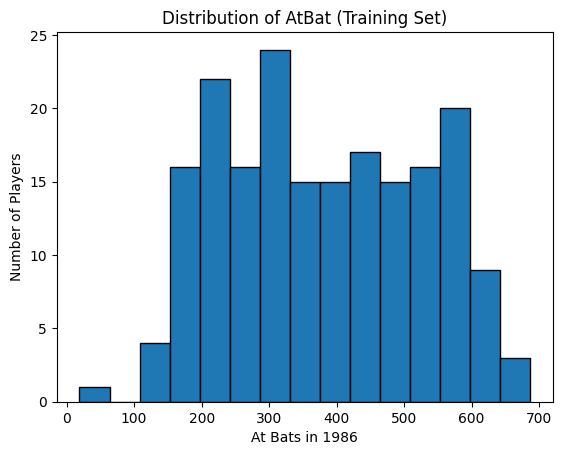

In [8]:
plt.hist(Train['AtBat'], bins=15, edgecolor='black')
plt.title('Distribution of AtBat (Training Set)')
plt.xlabel('At Bats in 1986')
plt.ylabel('Number of Players')
plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [9]:
Train = Train.copy()
Train['AtBat_st'] = (Train['AtBat'] - Train['AtBat'].mean()) / Train['AtBat'].std()
Train[['AtBat', 'AtBat_st']].head()

     AtBat  AtBat_st
3      496  0.783715
63     216 -1.138317
27     474  0.632698
130    306 -0.520521
93     511  0.886681

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [10]:
len(Train[Train['AtBat_st'].between(-1, 1)])

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

In the `describe()` output, `Salary` has a smaller `count` than the total number of rows in the training set. Because `describe()` excludes missing values, the difference between the row count and the Salary count is the number of missing Salary values.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

Missingness might not be revealed by `describe()` if missing values were encoded as ordinary values, such as 0, -999, or the string `Unknown`, rather than stored as `NaN`. Also, the default numeric summary excludes categorical columns, so missing values in a categorical variable would not appear in that output.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

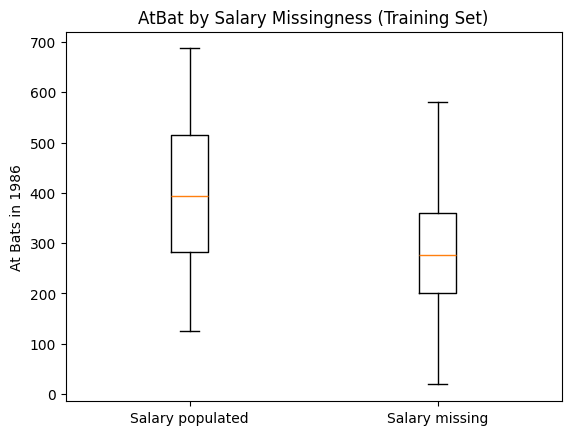

In [11]:
salary_groups = [
    Train.loc[Train['Salary'].notna(), 'AtBat'],
    Train.loc[Train['Salary'].isna(), 'AtBat']
]
plt.boxplot(salary_groups, tick_labels=['Salary populated', 'Salary missing'])
plt.title('AtBat by Salary Missingness (Training Set)')
plt.ylabel('At Bats in 1986')
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [12]:
Train.corr(numeric_only=True)

             AtBat      Hits     HmRun  ...    Errors    Salary  AtBat_st
AtBat     1.000000  0.963324  0.540323  ...  0.368162  0.401390  1.000000
Hits      0.963324  1.000000  0.516853  ...  0.301725  0.432558  0.963324
HmRun     0.540323  0.516853  1.000000  ...  0.062840  0.326021  0.540323
Runs      0.906579  0.914739  0.618439  ...  0.217297  0.441499  0.906579
RBI       0.798717  0.795316  0.840613  ...  0.217983  0.414623  0.798717
Walks     0.631824  0.605876  0.385425  ...  0.160753  0.458462  0.631824
Years    -0.039232 -0.028717  0.009072  ... -0.160476  0.541390 -0.039232
CAtBat    0.126602  0.133316  0.078981  ... -0.068187  0.616677  0.126602
CHits     0.146763  0.163329  0.076914  ... -0.062669  0.629875  0.146763
CHmRun    0.150166  0.136865  0.411917  ... -0.141514  0.616170  0.150166
CRuns     0.164892  0.175542  0.110767  ... -0.087724  0.649791  0.164892
CRBI      0.145779  0.153011  0.218285  ... -0.087897  0.641038  0.145779
CWalks    0.056578  0.065178  0.080296

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

1. Group players by similar `AtBat` values and impute each missing Salary with the median Salary of players in the same group. This uses the relationship suggested by the boxplots and is resistant to unusually high salaries.

2. Fit a regression model on rows with known Salary using the numeric variables most strongly correlated with Salary (for example, career-performance measures), then use the fitted model to predict the missing Salary values.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [13]:
TotHits = Train['Hits'].sum()
TotWalks = Train['Walks'].sum()
TotAtBat = Train['AtBat'].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

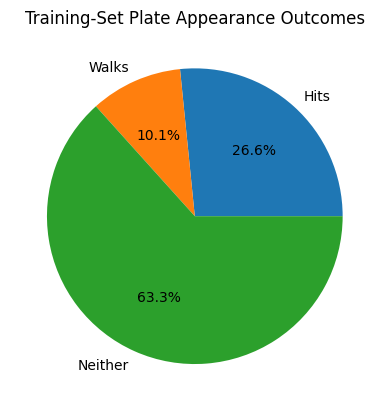

In [14]:
# pie chart
plt.pie(Totals, labels=Labels, autopct='%1.1f%%')
plt.title('Training-Set Plate Appearance Outcomes')
plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [15]:
Train['AVG'] = Train['Hits'] / Train['AtBat']
Train[['Hits', 'AtBat', 'AVG']].head()

     Hits  AtBat       AVG
3     141    496  0.284274
63     53    216  0.245370
27    129    474  0.272152
130   104    306  0.339869
93    138    511  0.270059

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [16]:
Train['AVG_bin'] = 'medium'
Train.loc[Train['AVG'] < 0.25, 'AVG_bin'] = 'low'
Train.loc[Train['AVG'] > 0.31, 'AVG_bin'] = 'high'

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [17]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    114
low        65
high       14
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [18]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

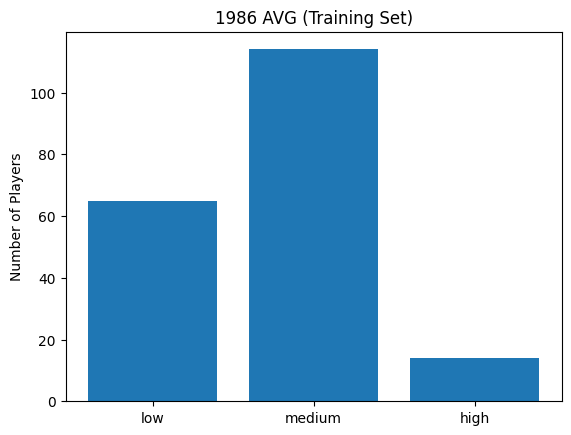

In [19]:
plt.bar(range(len(indexMap)), reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(range(len(indexMap)), indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

We used the **width method**. The bin boundaries were fixed in advance at 0.25 and 0.31, so the intervals have predetermined numeric widths and may contain different numbers of players. A depth method would instead choose cut points so that each bin contained approximately the same number of observations.